In [ ]:
!pip install sqlalchemy pymysql openpyxl requests python-dotenv

Defaulting to user installation because normal site-packages is not writeable


In [19]:
import datetime
import requests
import json
import os

from dotenv import load_dotenv
import pandas as pd
import sqlalchemy as sa
from sqlalchemy import create_engine, text, MetaData, Table
from sqlalchemy.orm import sessionmaker

# import warnings
# warnings.filterwarnings('ignore')

Завдання 1: Простий запит (1 бал)
Ми працюємо з БД Classicmodels.

Виведіть інформацію про продукти на складі з наступними полями:

назва продукту (productName)
лінійка продукту (productLine)
кількість на складі (quantityInStock)
ціна закупки (buyPrice)
Зчитайте дані з БД з допомогою pd.read_sql() з SQLAlchemy engine, який ви створили на етапі підготовки.

Виведіть перші 10 продуктів, відсортованих за кількістю на складі (від більшої кількості до меншої).

In [22]:
query = """
SELECT 
    productName, 
    productLine, 
    quantityInStock, 
    buyPrice
FROM products
ORDER BY quantityInStock DESC
LIMIT 10;
"""


try:
    df_products = pd.read_sql(query, engine)
    print("✅ Дані успішно завантажено!")
    display(df_products)
except Exception as e:
    print(f"❌ Помилка при виконанні запиту: {e}")

✅ Дані успішно завантажено!


,productName,productLine,quantityInStock,buyPrice
0,2002 Suzuki XREO,Motorcycles,9997,66.27
1,1995 Honda Civic,Classic Cars,9772,93.89
2,America West Airlines B757-200,Planes,9653,68.80
3,2002 Chevy Corvette,Classic Cars,9446,62.11
4,1932 Model A Ford J-Coupe,Vintage Cars,9354,58.48
5,1982 Ducati 996 R,Motorcycles,9241,24.14
6,1912 Ford Model T Delivery Wagon,Vintage Cars,9173,46.91
7,1976 Ford Gran Torino,Classic Cars,9127,73.49
8,1968 Dodge Charger,Classic Cars,9123,75.16
9,1965 Aston Martin DB5,Classic Cars,9042,65.96


Завдання 2: Аналітика замовлень за 2004 рік (3 бали)
Виведіть детальну інформацію про замовлення за 2004 рік з наступними полями:

Номер замовлення (orderNumber)
Дата замовлення (orderDate)
Статус замовлення (status)
Ім'я клієнта (customerName)
Країна клієнта (country)
Загальна сума замовлення (сума всіх orderdetails.quantityOrdered * orderdetails.priceEach)
Використайте JOIN для об'єднання таблиць orders, customers, orderdetails. Додайте параметризацію за роком (тільки замовлення за 2004 рік).

Використайте text() та named parameters для формування запиту з SQLAlchemy.

Після отримання даних з БД проведіть обчислення з Python та напишіть висновки:

Побудуйте стовпчасту діаграму суми замовлень по країнам і напишіть, в якій країні найбільша сума замовлень за 2004 рік.
В країні з найбільшою кількістю замовлень знайдіть клієнта, який зробив замовлень на найбільшу суму і виведіть імʼя цього клієнта, на яку суму він зробив замовлень і який % від всіх замовлень в цій країні становить його сума замовлень за рік.

In [23]:
from sqlalchemy import text
import matplotlib.pyplot as plt

query_2 = text("""
SELECT 
    o.orderNumber, 
    o.orderDate, 
    o.status, 
    c.customerName, 
    c.country,
    SUM(od.quantityOrdered * od.priceEach) AS totalOrderValue
FROM orders o
JOIN customers c ON o.customerNumber = c.customerNumber
JOIN orderdetails od ON o.orderNumber = od.orderNumber
WHERE YEAR(o.orderDate) = :order_year
GROUP BY o.orderNumber
""")

df_orders = pd.read_sql(query_2, engine, params={"order_year": 2004})

df_orders.head()

,orderNumber,orderDate,status,customerName,country,totalOrderValue
0,10208,2004-01-02,Shipped,"Saveley & Henriot, Co.",France,49614.72
1,10209,2004-01-09,Shipped,"Men 'R' US Retailers, Ltd.",USA,21053.69
2,10210,2004-01-12,Shipped,Osaka Souveniers Co.,Japan,47177.59
3,10211,2004-01-15,Shipped,Auto Canal+ Petit,France,49165.16
4,10212,2004-01-16,Shipped,Euro+ Shopping Channel,Spain,59830.55



### Завдання 3: Аналітичний запит - Топ продуктів по продажах (6 балів)

В цьому завданні ви отримуєте 1 бал за правильний SQL запит і по 1 балу за кожне завдання з Python.

**Проведіть аналіз прибутковості продуктів** та для цього дістаньте з БД інформацію з наступними полями:
- Назва продукту
- Лінійка продукту (productLine)
- Загальний дохід з цього продукту (сума quantity * priceEach)
- Ранг продукту по доходу (тобто яке місце посідає цей продукт за доходом серед усіх продуктів в нашому магазині)
- Який відсоток від загального доходу компанії складає цей продукт
- Різниця з середнім доходом по лінійці продукту (в %)

Відсортуйте дані за спаданням значень колонки "Який відсоток від загального доходу компанії складає цей продукт".

При створенні SQL запиту вам можуть стати в нагоді:
- **CTE** для розрахунку доходу по кожному продукту
- **Віконні функції** для ранжування та порівняння з середнім

Після отримання даних з БД проведіть обчислення (де треба) з Python та напишіть висновки:
1. Який відсоток від загального доходу складає ТОП1 продукт і що це за продукт?
2. Створіть стовпчикову діаграму топ-10 продуктів по доходу. В скільки разів відрізняється сумарний дохід за ТОП1 продуктом від 10го продукту за сумою доходу?
3. Створіть кругову діаграму розподілу доходу по лініях продуктів. Який відсоток від всіх продажів становлять продажі за ТОП2 лініями сумарно?
4. Розрахуйте та виведіть за принципом Парето (80/20) - скільки продуктів дають 80% доходу. Тобто нам треба знайти кількість продуктів сумарне значення "відсотку від загального доходу компанії", яких складає 80 починаючи з продукту з найбільшим цим відсотком.
5. Зробіть ще будь-яке аналітичне дослідження, яке дасть нам більше розуміння наших даних, що ми дістали в БД в цьому завданні. Сформоване питання до даних і обчислення має бути обовʼязково. Візуалізація - опціонально.

Візуалізацію можна створювати з будь-якою бібліотекою на ваш вибір.

In [24]:
query_3 = text("""
WITH ProductRevenue AS (
    SELECT 
        p.productName, 
        p.productLine,
        SUM(od.quantityOrdered * od.priceEach) AS productTotalRevenue
    FROM products p
    JOIN orderdetails od ON p.productCode = od.productCode
    GROUP BY p.productCode
),
CompanyStats AS (
    SELECT SUM(productTotalRevenue) AS grandTotal FROM ProductRevenue
)
SELECT 
    pr.productName,
    pr.productLine,
    pr.productTotalRevenue,
    RANK() OVER (ORDER BY pr.productTotalRevenue DESC) as productRank,
    (pr.productTotalRevenue / (SELECT grandTotal FROM CompanyStats)) * 100 as pctOfTotalRevenue,
    ((pr.productTotalRevenue - AVG(pr.productTotalRevenue) OVER (PARTITION BY pr.productLine)) / 
      AVG(pr.productTotalRevenue) OVER (PARTITION BY pr.productLine)) * 100 as diffFromLineAvgPct
FROM ProductRevenue pr
ORDER BY pctOfTotalRevenue DESC;
""")

df_analytics = pd.read_sql(query_3, engine)
df_analytics.head()

,productName,productLine,productTotalRevenue,productRank,pctOfTotalRevenue,diffFromLineAvgPct
0,1992 Ferrari 360 Spider red,Classic Cars,276839.98,1,2.882345,165.783219
1,2001 Ferrari Enzo,Classic Cars,190755.86,2,1.986072,83.137228
2,1952 Alpine Renault 1300,Classic Cars,190017.96,3,1.978390,82.428799
3,2003 Harley-Davidson Eagle Drag Bike,Motorcycles,170686.00,4,1.777113,97.779648
4,1968 Ford Mustang,Classic Cars,161531.48,5,1.681800,55.080046


In [25]:
top_1 = df_analytics.iloc[0]
print(f"ТОП-1 продукт: {top_1['productName']}")
print(f"Відсоток від загального доходу: {top_1['pctOfTotalRevenue']:.2f}%")

ТОП-1 продукт: 1992 Ferrari 360 Spider red
Відсоток від загального доходу: 2.88%


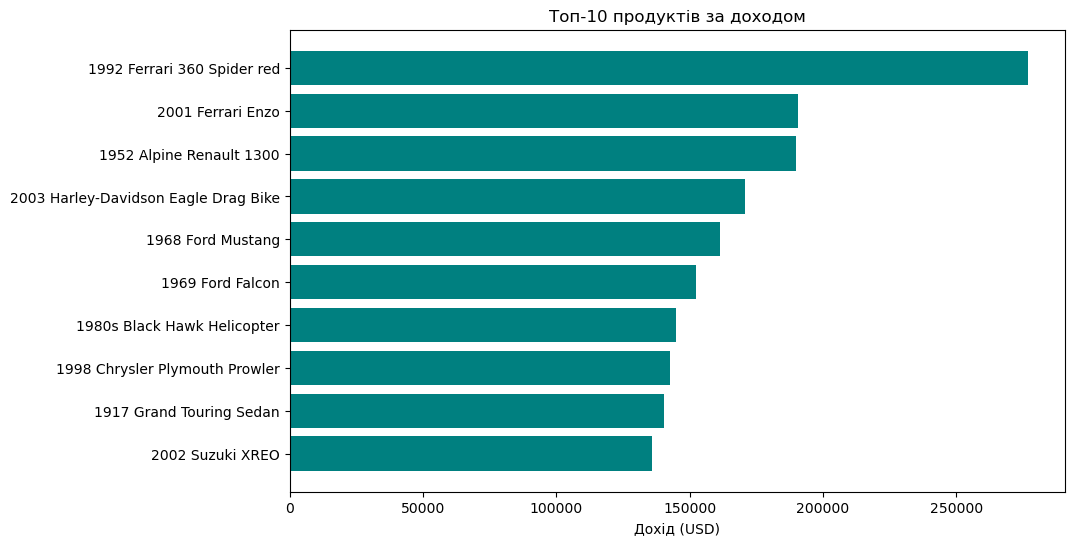

Дохід ТОП-1 продукту у 2.04 разів більший за дохід 10-го продукту.


In [26]:
top_10 = df_analytics.head(10)
plt.figure(figsize=(10, 6))
plt.barh(top_10['productName'][::-1], top_10['productTotalRevenue'][::-1], color='teal')
plt.title('Топ-10 продуктів за доходом')
plt.xlabel('Дохід (USD)')
plt.show()

ratio = top_10.iloc[0]['productTotalRevenue'] / top_10.iloc[9]['productTotalRevenue']
print(f"Дохід ТОП-1 продукту у {ratio:.2f} разів більший за дохід 10-го продукту.")

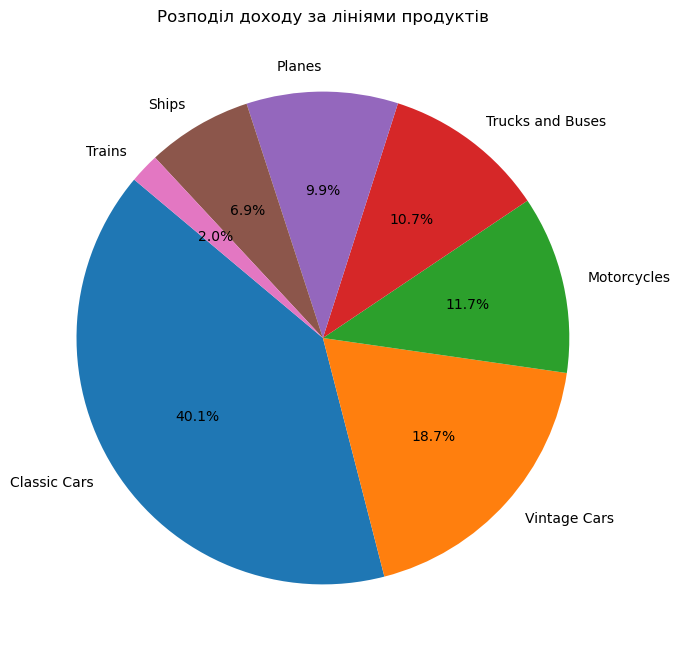

ТОП-2 лінії сумарно становлять 58.84% від усіх продажів.


In [27]:
line_revenue = df_analytics.groupby('productLine')['productTotalRevenue'].sum().sort_values(ascending=False)
plt.figure(figsize=(8, 8))
line_revenue.plot(kind='pie', autopct='%1.1f%%', startangle=140)
plt.title('Розподіл доходу за лініями продуктів')
plt.ylabel('')
plt.show()

top_2_lines_pct = (line_revenue.head(2).sum() / line_revenue.sum()) * 100
print(f"ТОП-2 лінії сумарно становлять {top_2_lines_pct:.2f}% від усіх продажів.")

In [28]:
df_analytics['cumulative_pct'] = df_analytics['pctOfTotalRevenue'].cumsum()
pareto_count = df_analytics[df_analytics['cumulative_pct'] <= 80].shape[0]
total_products = df_analytics.shape[0]

print(f"80% доходу забезпечують {pareto_count} продуктів (це {(pareto_count/total_products)*100:.1f}% від загальної кількості продуктів).")

80% доходу забезпечують 71 продуктів (це 65.1% від загальної кількості продуктів).


In [29]:
# Знайти максимальний diffFromLineAvgPct для кожної лінії
max_diff = df_analytics.groupby('productLine')['diffFromLineAvgPct'].max().sort_values(ascending=False)
print(f"Найбільший відрив лідера від середнього значення у лінії: {max_diff.idxmax()} ({max_diff.max():.2f}%)")

Найбільший відрив лідера від середнього значення у лінії: Classic Cars (165.78%)


ОПЦІОНАЛЬНО. Завдання 4: Аналітичний запит - Динаміка продажів по місяцях (8 балів)
Проведіть аналіз динаміки продажів по місяцях та для цього дістаньте з бази інформацію з наступними полями:

Рік та місяць замовлень

Кількість замовлень за цей рік-місяць

Загальний дохід (quantityOrdered * priceEach) за цей рік-місяць

На який % ми зросли за доходом порівняно з попереднім місяцем

Накопичувальний дохід до цього місяця за рік

Ковзне середнє доходу за 3 місяці

Ранг цього місяця за доходом

Використайте:



CTE для агрегації продажів по місяцях

Віконні функції для розрахунку:

Зростання доходу порівняно з попереднім місяцем (LAG)

Накопичувальний дохід за рік

Ковзне середнє доходу за 3 місяці (AVG OVER)

Ранжування місяців за доходом (RANK)

Після отримання даних з БД побудуйте наступні графіки і напишіть коротко, які висновки з них можна зробити.


Створіть лінійний графік доходу по місяцях. Чи є тред до зростання в даних?
Створіть графік місяць-до-місяця зростання у відсотках.
Створіть heatmap сезонності (місяць vs рік)
Відобразіть козвне середнє разом з динамікою продажів.
Розрахуйте кореляцію між кількістю замовлень та середнім чеком та побудуйте графік розсіювання між цими змінними. Чи є лінійна залежність?

In [31]:


query_4 = text("""
WITH MonthlySales AS (
    SELECT 
        YEAR(o.orderDate) as s_year,
        MONTH(o.orderDate) as s_month,
        COUNT(o.orderNumber) as orderCount,
        SUM(od.quantityOrdered * od.priceEach) as monthlyRevenue
    FROM orders o
    JOIN orderdetails od ON o.orderNumber = od.orderNumber
    GROUP BY s_year, s_month
)
SELECT 
    s_year, s_month, orderCount, monthlyRevenue,
    -- Зростання доходу (%) порівняно з попереднім місяцем
    ((monthlyRevenue - LAG(monthlyRevenue) OVER (ORDER BY s_year, s_month)) / 
      LAG(monthlyRevenue) OVER (ORDER BY s_year, s_month)) * 100 as growthPct,
    -- Накопичувальний дохід за рік
    SUM(monthlyRevenue) OVER (PARTITION BY s_year ORDER BY s_month) as runningTotalYear,
    -- Ковзне середнє за 3 місяці
    AVG(monthlyRevenue) OVER (ORDER BY s_year, s_month ROWS BETWEEN 2 PRECEDING AND CURRENT ROW) as movingAvg3Months,
    -- Ранг місяця за доходом
    RANK() OVER (ORDER BY monthlyRevenue DESC) as revenueRank
FROM MonthlySales
ORDER BY s_year, s_month;
""")
df_dynamic = pd.read_sql(query_4, engine)


df_dynamic['date'] = pd.to_datetime(
    df_dynamic[['s_year', 's_month']]
    .rename(columns={'s_year': 'year', 's_month': 'month'})
    .assign(day=1)
)

print("Дані після виправлення дат:")
display(df_dynamic.head())

Дані після виправлення дат:


,s_year,s_month,orderCount,monthlyRevenue,growthPct,runningTotalYear,movingAvg3Months,revenueRank,date
0,2003,1,39,116692.77,NaN,116692.77,116692.770000,29,2003-01-01
1,2003,2,41,128403.64,10.035643,245096.41,122548.205000,28,2003-02-01
2,2003,3,50,160517.14,25.009805,405613.55,135204.516667,26,2003-03-01
3,2003,4,58,185848.59,15.781150,591462.14,158256.456667,23,2003-04-01
4,2003,5,58,179435.55,-3.450680,770897.69,175267.093333,24,2003-05-01


In [38]:
df_dynamic['date'] = pd.to_datetime(df_dynamic['date'])
df_dynamic.sort_values('date').tail(10)

,s_year,s_month,orderCount,monthlyRevenue,growthPct,runningTotalYear,movingAvg3Months,revenueRank,date
20,2004,9,95,283799.80,-32.320185,2607541.50,342896.793333,16,2004-09-01
21,2004,10,159,500233.86,76.262936,3107775.36,401120.250000,4,2004-10-01
22,2004,11,301,979291.98,95.766832,4087067.34,587775.213333,2,2004-11-01
23,2004,12,141,428838.17,-56.209366,4515905.51,636121.336667,6,2004-12-01
24,2005,1,99,307737.02,-28.239359,307737.02,571955.723333,13,2005-01-01
25,2005,2,97,317192.17,3.072477,624929.19,351255.786667,12,2005-02-01
26,2005,3,117,359711.96,13.405057,984641.15,328213.716667,8,2005-03-01
27,2005,4,81,344820.62,-4.139796,1329461.77,340574.916667,9,2005-04-01
28,2005,5,129,441474.94,28.030319,1770936.71,382002.506667,5,2005-05-01
29,2026,3,2,488.10,-99.889439,488.10,262261.220000,30,2026-03-01


In [39]:
df_dynamic = df_dynamic[df_dynamic['date'] < '2006-01-01']

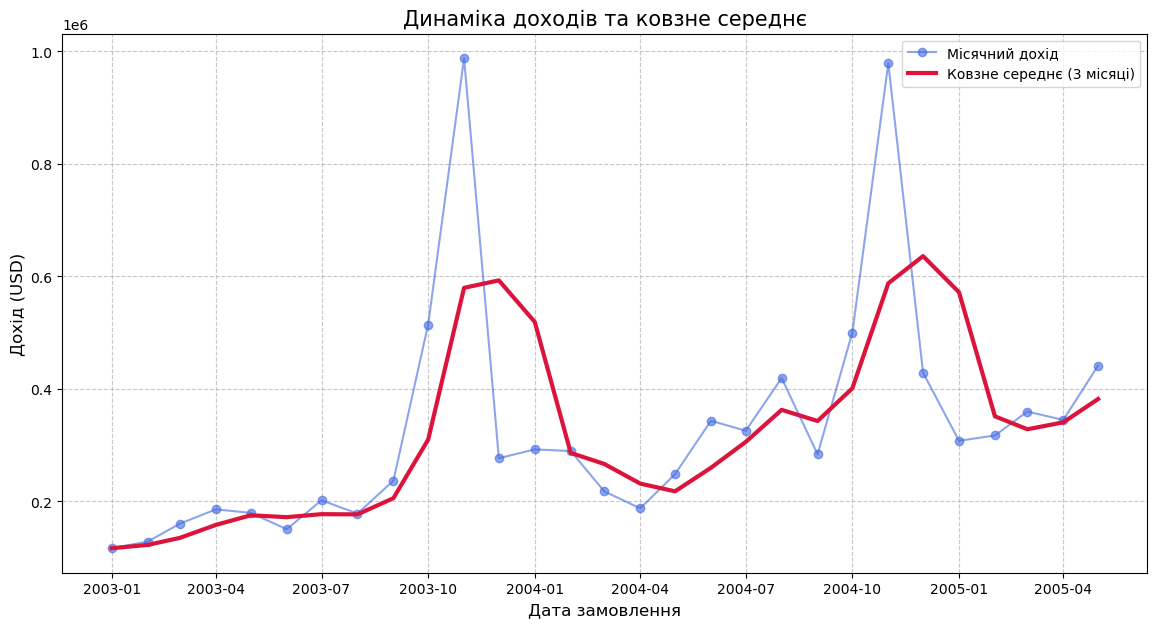

 Аналіз тренду 
Висновок: Спостерігається загальний тренд до зростання доходів порівняно з початковим періодом.


In [40]:
# лінійний графік доходу та ковзного середнього
plt.figure(figsize=(14, 7))

# Основна лінія доходу
plt.plot(df_dynamic['date'], df_dynamic['monthlyRevenue'], 
         marker='o', linestyle='-', color='royalblue', label='Місячний дохід', alpha=0.6)

# Лінія ковзного середнього (Moving Average)
plt.plot(df_dynamic['date'], df_dynamic['movingAvg3Months'], 
         color='crimson', linewidth=3, label='Ковзне середнє (3 місяці)')

# Оформлення
plt.title('Динаміка доходів та ковзне середнє', fontsize=15)
plt.xlabel('Дата замовлення', fontsize=12)
plt.ylabel('Дохід (USD)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

#  heatmap для висновків
plt.show()

# Розрахунок тренду для висновку
last_year_avg = df_dynamic[df_dynamic['s_year'] == df_dynamic['s_year'].max()]['monthlyRevenue'].mean()
first_year_avg = df_dynamic[df_dynamic['s_year'] == df_dynamic['s_year'].min()]['monthlyRevenue'].mean()

print(f" Аналіз тренду ")
if last_year_avg > first_year_avg:
    print("Висновок: Спостерігається загальний тренд до зростання доходів порівняно з початковим періодом.")
else:
    print("Висновок: Чіткого тренду до зростання не виявлено або спостерігається спад.")

C:\Users\Dell\AppData\Local\Temp\ipykernel_18260\594169894.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='date', y='growthPct', data=df_dynamic, palette='coolwarm')


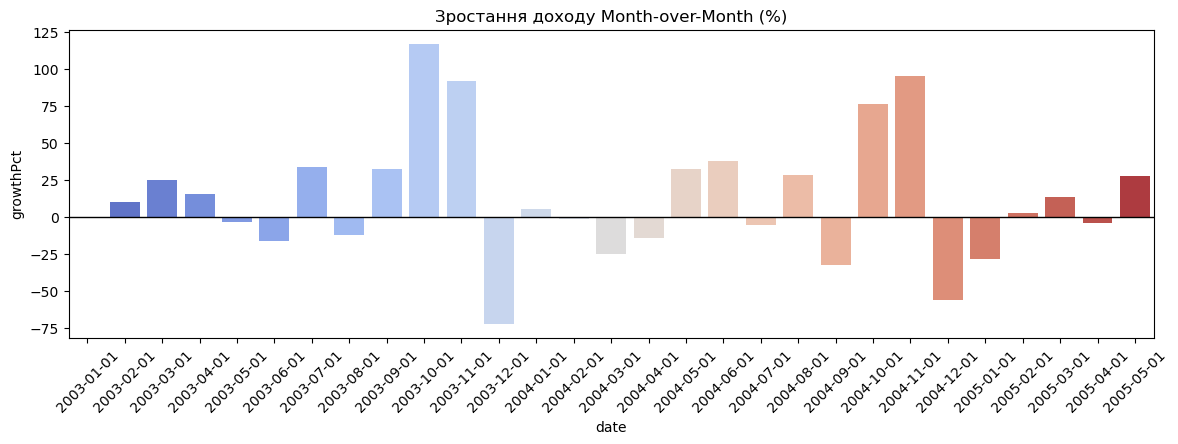

In [31]:
plt.figure(figsize=(14, 4))
sns.barplot(x='date', y='growthPct', data=df_dynamic, palette='coolwarm')
plt.axhline(0, color='black', linewidth=1)
plt.title('Зростання доходу Month-over-Month (%)')
plt.xticks(rotation=45)
plt.show()

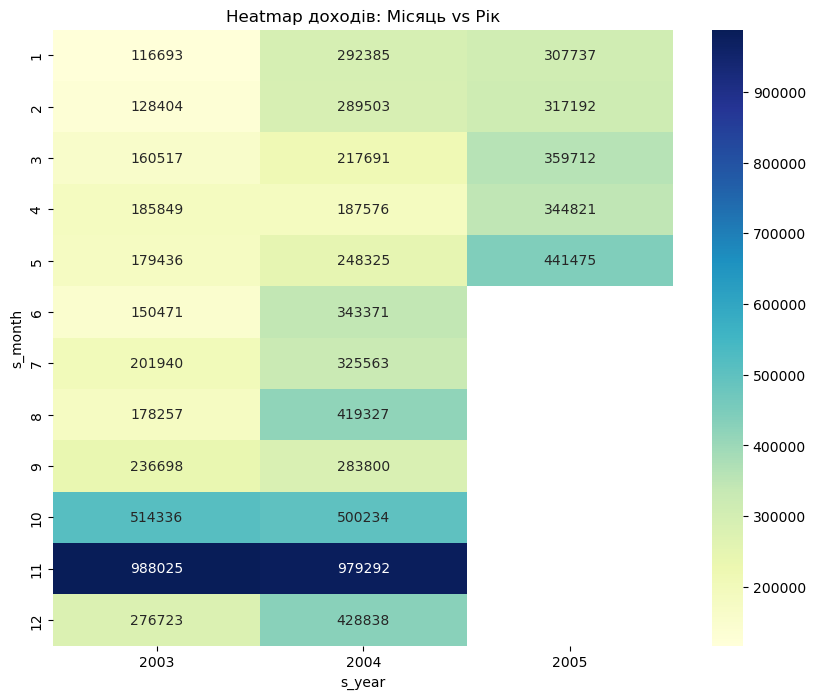

In [41]:
pivot_df = df_dynamic.pivot(index="s_month", columns="s_year", values="monthlyRevenue")
plt.figure(figsize=(10, 8))
sns.heatmap(pivot_df, annot=True, fmt=".0f", cmap="YlGnBu")
plt.title('Heatmap доходів: Місяць vs Рік')
plt.show()

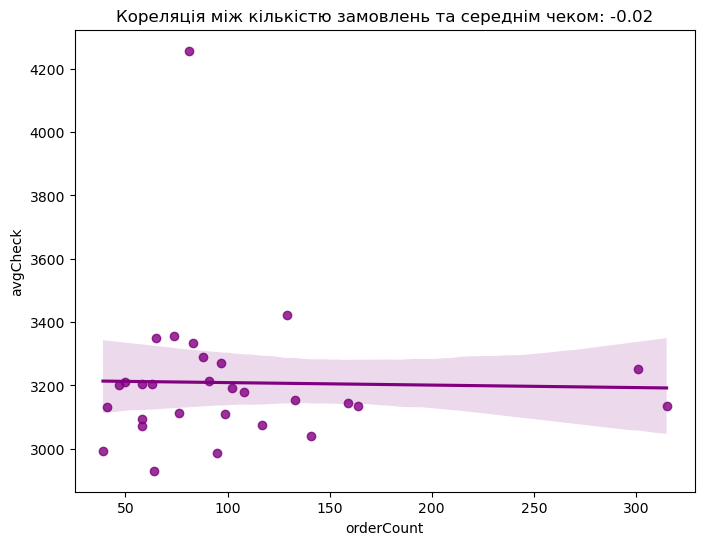

In [42]:
# Середній чек на місяць
df_dynamic['avgCheck'] = df_dynamic['monthlyRevenue'] / df_dynamic['orderCount']

correlation = df_dynamic['orderCount'].corr(df_dynamic['avgCheck'])

plt.figure(figsize=(8, 6))
sns.regplot(x='orderCount', y='avgCheck', data=df_dynamic, color='purple')
plt.title(f'Кореляція між кількістю замовлень та середнім чеком: {correlation:.2f}')
plt.show()

Бізнес має чітку сезонну модель: щороку в жовтні та листопаді спостерігається величезний стрибок продажів (дохід сягає майже 1 млн USD). Попри це, загальний тренд доходів йде вгору, це підтверджує червона лінія ковзного середнього. Зростання бізнесу відбувається саме завдяки збільшенню кількості замовлень, а не через подорожчання самих товарів, оскільки середній чек залишається стабільним незалежно від обсягів продажу.